<a href="https://colab.research.google.com/github/qiyazhao062-a11y/5151/blob/main/phase1_routeiq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RouteIQ: Multi-Agent ML System for Intelligent Customer Support Routing
## Phase 1: Data Loading, Exploration & Preprocessing

**Dataset:** Multilingual Customer Support Tickets  
**Target variable:** `queue` (10 classes — ticket routing destination)  
**Language:** English + German (all retained)  
**Class imbalance strategy:** `class_weight='balanced'` during model training  

## 0. Install Dependencies

In [ ]:
# Run this cell first in Google Colab
!pip install -q pandas numpy scikit-learn matplotlib seaborn

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

random.seed(42)
np.random.seed(42)
print('All imports successful.')

All imports successful.


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'ticket' in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/dba5113_project/RouteIQ/aa_dataset-tickets-multi-lang-5-2-50-version.csv


## 2. Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/dba5113_project/RouteIQ/aa_dataset-tickets-multi-lang-5-2-50-version.csv'

df = pd.read_csv(DATA_PATH)
assert len(df) > 0, 'Dataset loaded empty — check DATA_PATH.'
print(f'Dataset loaded successfully: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully: 28,587 rows x 16 columns


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


## 3. Data Exploration

In [ ]:
# ── Column types and basic info ──────────────────────────────────────────────
print('Column info:')
df.info()

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   24749 non-null  object
 1   body      28587 non-null  object
 2   answer    28580 non-null  object
 3   type      28587 non-null  object
 4   queue     28587 non-null  object
 5   priority  28587 non-null  object
 6   language  28587 non-null  object
 7   version   28587 non-null  int64 
 8   tag_1     28587 non-null  object
 9   tag_2     28574 non-null  object
 10  tag_3     28451 non-null  object
 11  tag_4     25529 non-null  object
 12  tag_5     14545 non-null  object
 13  tag_6     5874 non-null   object
 14  tag_7     2040 non-null   object
 15  tag_8     565 non-null    object
dtypes: int64(1), object(15)
memory usage: 3.5+ MB


In [ ]:
# ── Missing value audit ──────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]
print('Columns with missing values:')
print(missing_report)

Columns with missing values:
         Missing Count  Missing %
subject           3838       13.4
answer               7        0.0
tag_2               13        0.0
tag_3              136        0.5
tag_4             3058       10.7
tag_5            14042       49.1
tag_6            22713       79.5
tag_7            26547       92.9
tag_8            28022       98.0


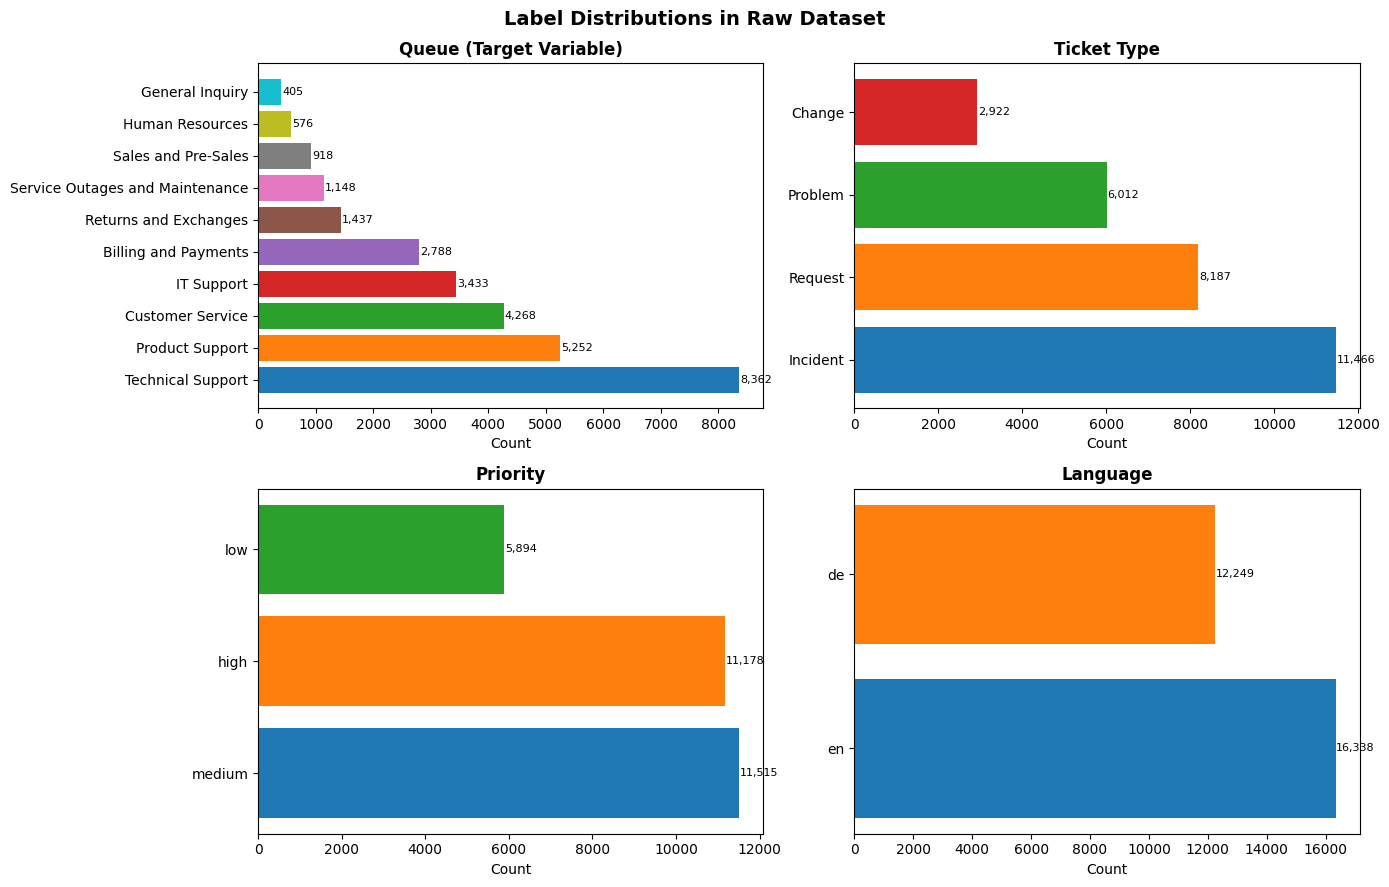

Saved: label_distributions.png


In [ ]:
# ── Label distributions ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Label Distributions in Raw Dataset', fontsize=14, fontweight='bold')

for ax, col, title in zip(
    axes.flat,
    ['queue', 'type', 'priority', 'language'],
    ['Queue (Target Variable)', 'Ticket Type', 'Priority', 'Language']
):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values, color=sns.color_palette('tab10', len(counts)))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: label_distributions.png')

In [ ]:
# ── Class imbalance assessment ───────────────────────────────────────────────
queue_counts = df['queue'].value_counts()
imbalance_ratio = queue_counts.max() / queue_counts.min()
print('Queue class distribution:')
print(queue_counts)
print(f'\nImbalance ratio (max/min): {imbalance_ratio:.1f}x')
print('\nDecision: Use class_weight="balanced" during model training.')
print('This tells the model to penalise errors on minority classes more heavily,')
print('without altering the training data itself.')

Queue class distribution:
queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

Imbalance ratio (max/min): 20.6x

Decision: Use class_weight="balanced" during model training.
This tells the model to penalise errors on minority classes more heavily,
without altering the training data itself.


In [ ]:
# ── Text length analysis ─────────────────────────────────────────────────────
df['body_len'] = df['body'].fillna('').str.len()
df['subject_len'] = df['subject'].fillna('').str.len()

print('Body character length stats:')
print(df['body_len'].describe().round(0))
print('\nSubject character length stats:')
print(df['subject_len'].describe().round(0))

# Drop temporary columns
df.drop(columns=['body_len', 'subject_len'], inplace=True)

Body character length stats:
count    28587.0
mean       387.0
std        200.0
min          6.0
25%        219.0
50%        386.0
75%        551.0
max       1469.0
Name: body_len, dtype: float64

Subject character length stats:
count    28587.0
mean        39.0
std         24.0
min          0.0
25%         27.0
50%         39.0
75%         51.0
max        675.0
Name: subject_len, dtype: float64


## 4. Preprocessing

**Decisions documented here (for report & SKILL.md):**
- `subject` (3,838 missing, ~13%): fill with empty string and concatenate with `body`
- `answer` (7 missing): drop those 7 rows — too few to impute meaningfully
- `tag_1`–`tag_3`: nearly complete, but are multi-value categorical labels (e.g. "Security", "Outage") that risk target leakage and require complex multi-hot encoding — excluded
- `tag_4`–`tag_8`: >10% to >98% missing — additionally excluded
- `version`: constant value (51) — provides no signal, dropped
- Language: retain both English and German — supports multilingual routing

In [ ]:
# ── 4.1 Drop rows where answer is missing (only 7 rows) ─────────────────────
before = len(df)
df = df.dropna(subset=['answer'])
print(f'Dropped {before - len(df)} rows with missing answer. Remaining: {len(df):,}')

# ── 4.2 Fill missing subject with empty string ────────────────────────────────
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')

# ── 4.3 Combine subject + body into a single text feature ────────────────────
# Subject acts as a short title; body contains the main content.
# Concatenating gives TF-IDF access to all available text signal.
df['text'] = df['subject'].str.strip() + ' ' + df['body'].str.strip()
df['text'] = df['text'].str.strip()

# ── 4.4 Drop columns not used as features ────────────────────────────────────
cols_to_drop = ['subject', 'body', 'answer', 'version',
                'tag_1', 'tag_2', 'tag_3', 'tag_4',
                'tag_5', 'tag_6', 'tag_7', 'tag_8']
df = df.drop(columns=cols_to_drop)

print(f'\nColumns retained: {list(df.columns)}')
print(f'Final dataset shape: {df.shape}')
df.head(3)

Dropped 7 rows with missing answer. Remaining: 28,580

Columns retained: ['type', 'queue', 'priority', 'language', 'text']
Final dataset shape: (28580, 5)


,type,queue,priority,language,text
0,Incident,Technical Support,high,de,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...
1,Incident,Technical Support,high,en,"Account Disruption Dear Customer Support Team,..."
2,Request,Returns and Exchanges,medium,en,Query About Smart Home System Integration Feat...


In [ ]:
# ── 4.5 Label encode the target variable (queue) ─────────────────────────────
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['queue'])

print('Queue → Encoded label mapping:')
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {i}: {cls}')

NUM_CLASSES = len(label_encoder.classes_)
print(f'\nTotal classes: {NUM_CLASSES}')

Queue → Encoded label mapping:
  0: Billing and Payments
  1: Customer Service
  2: General Inquiry
  3: Human Resources
  4: IT Support
  5: Product Support
  6: Returns and Exchanges
  7: Sales and Pre-Sales
  8: Service Outages and Maintenance
  9: Technical Support

Total classes: 10


## 5. TF-IDF Vectorisation & Train / Val / Test Split

**Split ratios:** 80% train / 10% validation / 10% test  
**Stratified** on `queue` to preserve class proportions across all three sets  
**TF-IDF fitted on training set only** — vectoriser then applied to val and test

In [ ]:
# ── 5.1 Raw text / label arrays ──────────────────────────────────────────────
X_raw = df['text'].values
y = df['label'].values

# ── 5.2 First split: 90% temp + 10% test ─────────────────────────────────────
X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

# ── 5.3 Second split: 80% train + 10% val (from the 90% temp) ────────────────
# 0.111 of 90% ≈ 10% of total
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.111,
    stratify=y_temp,
    random_state=42
)

print(f'Train size : {len(X_train_raw):,} ({len(X_train_raw)/len(X_raw)*100:.1f}%)')
print(f'Val size   : {len(X_val_raw):,} ({len(X_val_raw)/len(X_raw)*100:.1f}%)')
print(f'Test size  : {len(X_test_raw):,} ({len(X_test_raw)/len(X_raw)*100:.1f}%)')

Train size : 22,866 (80.0%)
Val size   : 2,856 (10.0%)
Test size  : 2,858 (10.0%)


In [ ]:
# ── 5.4 TF-IDF Vectorisation ─────────────────────────────────────────────────
# German stopwords (dataset is bilingual EN+DE); accent-stripped forms included
GERMAN_STOPWORDS = [
    'die', 'der', 'und', 'in', 'den', 'von', 'zu', 'das', 'mit', 'sich',
    'des', 'auf', 'fur', 'ist', 'im', 'dem', 'nicht', 'ein', 'eine', 'als',
    'auch', 'es', 'an', 'werden', 'aus', 'er', 'hat', 'dass', 'sie', 'nach',
    'wird', 'bei', 'einer', 'um', 'am', 'sind', 'noch', 'wie', 'einem',
    'uber', 'einen', 'so', 'zum', 'haben', 'oder', 'ich', 'wir', 'kann',
    'durch', 'wenn', 'aber', 'dieser', 'diesem', 'diese', 'dieses',
    'mehr', 'mich', 'mir', 'uns', 'war', 'were', 'konnen', 'wurde', 'wurden'
]

# Configuration rationale:
#   max_features=10000  : keeps vocabulary manageable; avoids noise from rare terms
#   ngram_range=(1,2)   : captures single words and two-word phrases
#   sublinear_tf=True   : log-scale term frequency dampens high-frequency words
#   min_df=2            : ignores terms appearing in fewer than 2 documents
#   stop_words          : removes English and German stopwords so model learns
#                         meaningful content words, not grammatical filler

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
combined_stopwords = list(ENGLISH_STOP_WORDS) + GERMAN_STOPWORDS

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    analyzer='word',
    stop_words=combined_stopwords
)

# Fit ONLY on training data, then transform all three sets
X_train = vectorizer.fit_transform(X_train_raw)
X_val   = vectorizer.transform(X_val_raw)
X_test  = vectorizer.transform(X_test_raw)

print('TF-IDF matrix shapes:')
print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'Vocabulary size: {len(vectorizer.vocabulary_):,}')

TF-IDF matrix shapes:
  X_train : (22866, 10000)
  X_val   : (2856, 10000)
  X_test  : (2858, 10000)
Vocabulary size: 10,000


In [ ]:
# ── 5.5 Verify stratification ────────────────────────────────────────────────
split_summary = pd.DataFrame({
    'Train %': pd.Series(y_train).value_counts(normalize=True).sort_index() * 100,
    'Val %'  : pd.Series(y_val  ).value_counts(normalize=True).sort_index() * 100,
    'Test %' : pd.Series(y_test ).value_counts(normalize=True).sort_index() * 100,
}).round(1)
split_summary.index = label_encoder.classes_
print('Class proportions across splits (should be similar):')
print(split_summary)

Class proportions across splits (should be similar):
                                 Train %  Val %  Test %
Billing and Payments                 9.8    9.7     9.7
Customer Service                    14.9   14.9    14.9
General Inquiry                      1.4    1.4     1.4
Human Resources                      2.0    2.0     2.0
IT Support                          12.0   12.0    12.0
Product Support                     18.4   18.3    18.4
Returns and Exchanges                5.0    5.0     5.0
Sales and Pre-Sales                  3.2    3.2     3.2
Service Outages and Maintenance      4.0    4.0     4.0
Technical Support                   29.3   29.3    29.3


## 6. Mock Order Records

The `lookup-order-record` agent skill requires a customer/order database.  
Since no real order data exists, we simulate a realistic mock dataset of 300 records.

In [ ]:
random.seed(42)
np.random.seed(42)

N = 300

products = ['CloudPro Basic', 'CloudPro Business', 'CloudPro Enterprise',
            'SecureVPN', 'DataSync', 'SupportDesk Lite', 'SupportDesk Pro']
statuses = ['Active', 'Active', 'Active', 'Suspended', 'Trial', 'Cancelled']
regions  = ['EMEA', 'APAC', 'NA', 'LATAM']
plans    = ['Monthly', 'Annual', 'Bi-Annual']

mock_orders = pd.DataFrame({
    'ticket_id'      : [f'TKT-{i:05d}' for i in range(N)],
    'customer_id'    : [f'CUST-{random.randint(1000, 9999)}' for _ in range(N)],
    'customer_name'  : [f'Customer {i}' for i in range(N)],
    'account_status' : random.choices(statuses, k=N),
    'product'        : random.choices(products, k=N),
    'plan'           : random.choices(plans, k=N),
    'region'         : random.choices(regions, k=N),
    'open_tickets'   : np.random.randint(0, 5, size=N),
    'last_order_date': pd.date_range('2023-01-01', periods=N, freq='D').strftime('%Y-%m-%d').tolist(),
    'contract_value_usd': np.random.choice([500, 1200, 3600, 9600, 24000], size=N)
})

print(f'Mock orders created: {len(mock_orders)} records')
mock_orders.head(5)

Mock orders created: 300 records


,ticket_id,customer_id,customer_name,account_status,product,plan,region,open_tickets,last_order_date,contract_value_usd
0,TKT-00000,CUST-2824,Customer 0,Suspended,CloudPro Basic,Monthly,APAC,3,2023-01-01,24000
1,TKT-00001,CUST-1409,Customer 1,Cancelled,SupportDesk Pro,Annual,NA,4,2023-01-02,24000
2,TKT-00002,CUST-5506,Customer 2,Suspended,DataSync,Monthly,EMEA,2,2023-01-03,500
3,TKT-00003,CUST-5012,Customer 3,Active,SupportDesk Lite,Annual,APAC,4,2023-01-04,24000
4,TKT-00004,CUST-4657,Customer 4,Trial,DataSync,Annual,EMEA,4,2023-01-05,3600


## 7. Agent State — Save All Preprocessing Outputs

Everything produced in Phase 1 is stored in `agent_state` — a shared dictionary  
that acts as memory passed between all LangGraph agent nodes.

In [ ]:
import collections, pickle, os

# Majority class — DummyClassifier is fitted and scored in Phase 2
majority_class_label = collections.Counter(y_train).most_common(1)[0][0]
majority_class_name  = label_encoder.inverse_transform([majority_class_label])[0]
print(f'Majority class (baseline reference for Phase 2): "{majority_class_name}"')

agent_state = {
    # ── TF-IDF matrices ──────────────────────────────────────────────────────
    'X_train': X_train,
    'X_val'  : X_val,
    'X_test' : X_test,

    # ── Labels ───────────────────────────────────────────────────────────────
    'y_train': y_train,
    'y_val'  : y_val,
    'y_test' : y_test,

    # ── Fitted objects (needed at inference time) ─────────────────────────────
    'vectorizer'    : vectorizer,
    'label_encoder' : label_encoder,

    # ── Baseline reference (DummyClassifier evaluated in Phase 2) ─────────────
    'majority_class_name': majority_class_name,

    # ── Raw text (useful for error analysis in Phase 2) ───────────────────────
    'X_test_raw': X_test_raw,

    # ── Mock order records ────────────────────────────────────────────────────
    'mock_orders': mock_orders,

    # ── Preprocessing notes (for report & SKILL.md) ───────────────────────────
    'preprocessing_notes': {
        'target_variable'      : 'queue',
        'num_classes'          : NUM_CLASSES,
        'class_names'          : list(label_encoder.classes_),
        'languages_retained'   : ['de', 'en'],
        'missing_subject_fill' : 'empty string, concatenated with body',
        'missing_answer_drop'  : '7 rows dropped (answer is not a model feature; rows unusable without it)',
        'tags_excluded'        : (
            'tag_1–tag_3: multi-value categorical labels that risk target leakage '
            'and require complex multi-hot encoding; '
            'tag_4–tag_8: additionally have 10%–98% missing values. '
            'subject+body text provides sufficient signal without tags.'
        ),
        'text_feature'         : 'subject + body concatenated → text column',
        'imbalance_strategy'   : 'class_weight="balanced" applied at model training',
        'tfidf_config'         : {
            'max_features' : 10000,
            'ngram_range'  : '(1, 2)',
            'sublinear_tf' : True,
            'min_df'       : 2,
            'strip_accents': 'unicode'
        },
        'split_ratios'         : '80% train / 10% val / 10% test (stratified on queue)',
        'train_size'           : len(X_train_raw),
        'val_size'             : len(X_val_raw),
        'test_size'            : len(X_test_raw),
        'majority_class'       : majority_class_name,
    }
}

os.makedirs('outputs', exist_ok=True)
with open('outputs/agent_state_phase1.pkl', 'wb') as f:
    pickle.dump(agent_state, f)

print('agent_state saved to outputs/agent_state_phase1.pkl')
print('\nKeys in agent_state:')
for k, v in agent_state.items():
    if hasattr(v, 'shape'):
        print(f'  {k}: shape={v.shape}')
    elif isinstance(v, pd.DataFrame):
        print(f'  {k}: DataFrame {v.shape}')
    elif isinstance(v, dict):
        print(f'  {k}: dict with {len(v)} entries')
    else:
        print(f'  {k}: {type(v).__name__}')

Majority class (baseline reference for Phase 2): "Technical Support"
agent_state saved to outputs/agent_state_phase1.pkl

Keys in agent_state:
  X_train: shape=(22866, 10000)
  X_val: shape=(2856, 10000)
  X_test: shape=(2858, 10000)
  y_train: shape=(22866,)
  y_val: shape=(2856,)
  y_test: shape=(2858,)
  vectorizer: TfidfVectorizer
  label_encoder: LabelEncoder
  majority_class_name: str
  X_test_raw: shape=(2858,)
  mock_orders: shape=(300, 10)
  preprocessing_notes: dict with 15 entries


## 8. Phase 1 Summary

| Item | Decision | Rationale |
|---|---|---|
| Target variable | `queue` (10 classes) | RouteIQ routes tickets to the correct support queue |
| Languages | English + German | Larger dataset; demonstrates multilingual capability |
| Missing `subject` | Fill with `''` | Retain rows; body still provides full signal |
| Missing `answer` | Drop 7 rows | Not a model feature; rows are unusable without a response |
| Tags excluded | `tag_1`–`tag_8` | tag_1–3: leakage risk + complex encoding; tag_4–8: high missingness |
| Class imbalance | `class_weight='balanced'` | Avoids oversampling artefacts; applied at training time |
| Features | TF-IDF on `subject`+`body` | Standard NLP baseline; fair for both candidate models |
| Split | 80/10/10 stratified | Stratify ensures minority classes present in all splits |

**Next step → Phase 2:** Train Logistic Regression and Random Forest, fit DummyClassifier baseline, evaluate all three on `X_test`.

In [ ]:
import collections, numpy as np

print('=== 1. SPLIT SIZES ===')
total = len(y_train)+len(y_val)+len(y_test)
print(f'train={len(y_train):,}  val={len(y_val):,}  test={len(y_test):,}')
print(f'ratios: {len(y_train)/total*100:.1f}% / {len(y_val)/total*100:.1f}% / {len(y_test)/total*100:.1f}%')

print('\n=== 2. STRATIFICATION ===')
print(f'{"Queue":<30} {"Train%":>7} {"Val%":>7} {"Test%":>7}')
for i, cls in enumerate(label_encoder.classes_):
    tr = (y_train==i).sum()/len(y_train)*100
    va = (y_val==i).sum()/len(y_val)*100
    te = (y_test==i).sum()/len(y_test)*100
    print(f'{cls:<30} {tr:>7.1f} {va:>7.1f} {te:>7.1f}')

print('\n=== 3. IMBALANCE RATIO ===')
cnts = collections.Counter(y_train)
for i, cls in enumerate(label_encoder.classes_):
    print(f'  {cls:<30} {cnts[i]:>5}')
ratio = max(cnts.values())/min(cnts.values())
print(f'imbalance ratio: {ratio:.1f}x → class_weight=balanced justified: {"YES" if ratio>3 else "NO"}')

print('\n=== 4. TOP TFIDF TERMS PER QUEUE ===')
feat = vectorizer.get_feature_names_out()
for i, cls in enumerate(label_encoder.classes_):
    idx = np.where(y_train==i)[0]
    mean_w = np.asarray(X_train[idx].mean(axis=0)).flatten()
    top5 = [feat[j] for j in mean_w.argsort()[-5:][::-1]]
    print(f'  {cls:<30} {top5}')


=== 1. SPLIT SIZES ===
train=22,866  val=2,856  test=2,858
ratios: 80.0% / 10.0% / 10.0%

=== 2. STRATIFICATION ===
Queue                           Train%    Val%   Test%
Billing and Payments               9.8     9.7     9.7
Customer Service                  14.9    14.9    14.9
General Inquiry                    1.4     1.4     1.4
Human Resources                    2.0     2.0     2.0
IT Support                        12.0    12.0    12.0
Product Support                   18.4    18.3    18.4
Returns and Exchanges              5.0     5.0     5.0
Sales and Pre-Sales                3.2     3.2     3.2
Service Outages and Maintenance     4.0     4.0     4.0
Technical Support                 29.3    29.3    29.3

=== 3. IMBALANCE RATIO ===
  Billing and Payments            2230
  Customer Service                3414
  General Inquiry                  324
  Human Resources                  461
  IT Support                      2747
  Product Support                 4200
  Returns and Ex

In [ ]:
feat = vectorizer.get_feature_names_out()
X_dense = X_train.toarray()

print('=== DISCRIMINATIVE TERMS PER QUEUE ===')
print('(words that appear more in this queue than all others combined)\n')
for i, cls in enumerate(label_encoder.classes_):
    this_class  = X_dense[y_train == i].mean(axis=0)
    other_class = X_dense[y_train != i].mean(axis=0)
    diff = this_class - other_class
    top5 = [feat[j] for j in diff.argsort()[-5:][::-1]]
    print(f'  {cls:<30} {top5}')


=== DISCRIMINATIVE TERMS PER QUEUE ===
(words that appear more in this queue than all others combined)

  Billing and Payments           ['billing', 'payment', 'subscription', 'discrepancies', 'invoice']
  Customer Service               ['details', 'strategies', 'integration', 'brand', 'integrating']
  General Inquiry                ['engagement', 'enhance', 'audience', 'strategies', 'results']
  Human Resources                ['employee', 'access', 'onboarding', 'hr', 'today']
  IT Support                     ['server', 'network', 'devices', 'tools', 'software']
  Product Support                ['engagement', 'campaigns', 'brand', 'campaign', 'targeting']
  Returns and Exchanges          ['returns', 'investment', 'return', 'investment returns', 'engagement']
  Sales and Pre-Sales            ['details', 'solutions', 'saas', 'sales', 'pricing']
  Service Outages and Maintenance ['service', 'outage', 'outages', 'disruption', 'service outage']
  Technical Support              ['software',

Discriminative term analysis confirmed that the TF-IDF feature space captures meaningful business signals for most queue categories. Billing and Payments tickets are characterised by terms such as 'billing', 'payment', and 'invoice', while Service Outages tickets are dominated by 'outage', 'disruption', and 'server'. The 20.6x class imbalance ratio between Technical Support (n=6,689) and General Inquiry (n=324) justified the use of class_weight='balanced' during model training